<a href="https://colab.research.google.com/github/Lalitmohan6376/Email-spam-Detection---Using-Artificial---Neural--Network-ANN-/blob/main/Spam_Email_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout



In [104]:
df = pd.read_csv("spam_email_dataset.csv")
df

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,22,136,0,5,1,0,0,fefsrcz@unknownmail.cc,unknownmail.cc,0.68,8,1,0,29,1,1,1
9996,9996,You are selected!!!,click now free guarantee free win click now wi...,26,158,0,2,0,0,0,yxyctux@chealdealz.xyz,chealdealz.xyz,0.76,2,3,0,29,0,1,1
9997,9997,You are selected!!!,offer cash win limited click now cash limited ...,21,124,0,3,1,1,1,tkvqnki@unknownmail.cc,unknownmail.cc,0.69,6,1,0,25,0,1,1
9998,9998,Meeting Reminder,budget review - Many result affect idea.,7,40,0,1,0,2,1,wmvnrbn@outlook.com,outlook.com,0.80,7,2,0,18,0,0,0


In [105]:
df['label'].value_counts()

,count
label,
0,6005
1,3995


In [106]:
df.columns

Index(['email_id', 'subject', 'email_text', 'num_words', 'num_characters',
       'num_exclamation_marks', 'num_links', 'has_suspicious_link',
       'num_attachments', 'has_attachment', 'sender_email', 'sender_domain',
       'sender_reputation_score', 'email_hour', 'email_day_of_week',
       'is_weekend', 'num_recipients', 'contains_money_terms',
       'contains_urgency_terms', 'label'],
      dtype='object')

In [107]:
# 1. Histogram - Email Length (num_words)
def plot_num_words(df):
    plt.figure(figsize=(8,5))
    plt.hist(df['num_words'], bins=30)
    plt.title("Distribution of Email Word Count")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

In [108]:
 # 2. Count Plot - Spam vs Ham (label)
def plot_label_distribution(df):
    plt.figure(figsize=(6,4))
    sns.countplot(x=df['label'])
    plt.title("Spam vs Ham Distribution")
    plt.show()


In [109]:

# 3. Boxplot - Sender Reputation vs Label
def plot_reputation_vs_label(df):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df['label'], y=df['sender_reputation_score'])
    plt.title("Sender Reputation vs Label")
    plt.show()


In [110]:
# 4. Bar Plot - Average Links per Label
def plot_links_by_label(df):
    avg_links = df.groupby('label')['num_links'].mean()

    plt.figure(figsize=(6,4))
    avg_links.plot(kind='bar')
    plt.title("Average Number of Links by Label")
    plt.xlabel("Label")
    plt.ylabel("Average Links")
    plt.show()


In [111]:

# MAIN FUNCTION (loop use)
def run_all_visualizations(df):
    functions = [
        plot_num_words,
        plot_label_distribution,
        plot_reputation_vs_label,
        plot_links_by_label,
    ]

    for func in functions:
        func(df)

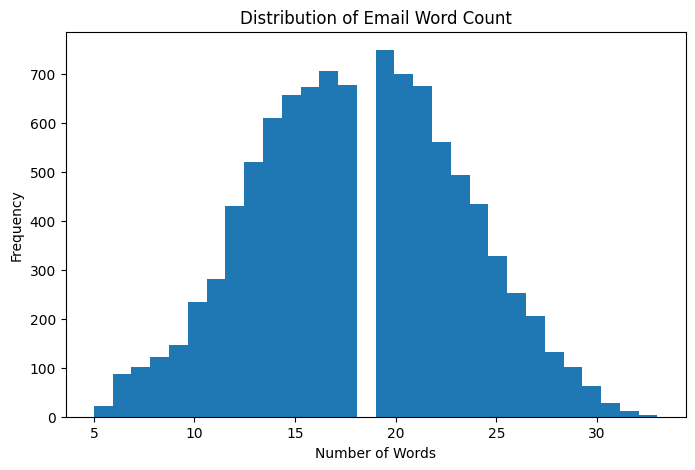

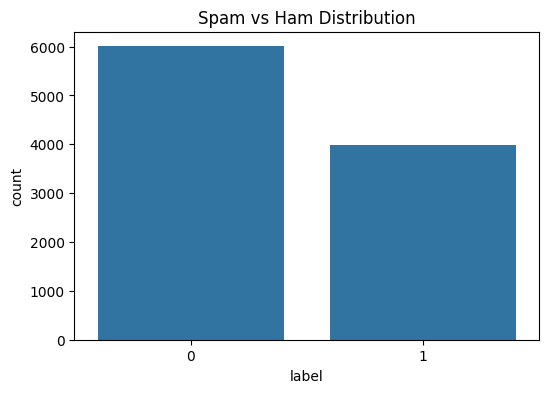

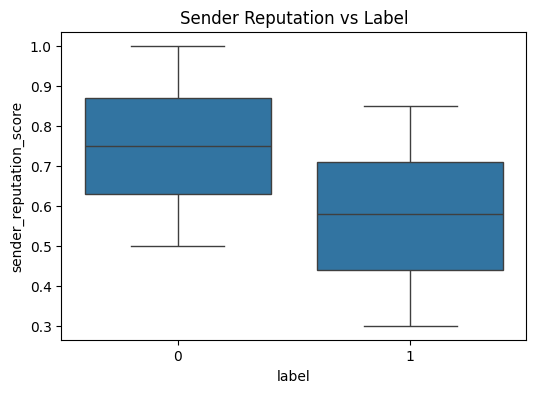

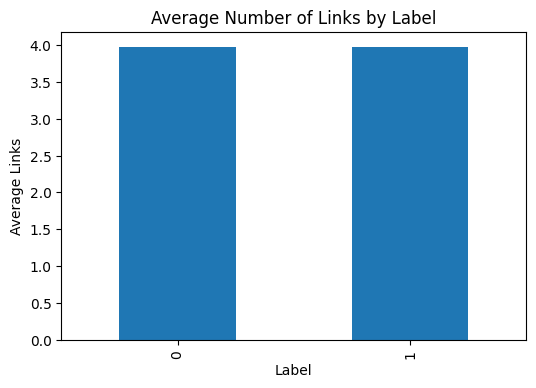

In [112]:
run_all_visualizations(df)

In [113]:

drop_cols = ['email_id', 'sender_email', 'sender_domain']
df = df.drop(columns=drop_cols)

# -------------------------------
# 3. HANDLE MISSING VALUES
# -------------------------------
df = df.dropna()

# -------------------------------
# 4. SPLIT FEATURES & TARGET
# -------------------------------
X = df.drop(columns=['label'])
y = df['label']

# -------------------------------
# 5. TRAIN TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 6. HANDLE IMBALANCED DATA (ONLY TRAIN)
# -------------------------------
train_df = pd.concat([X_train, y_train], axis=1)

# Separate classes
class_0 = train_df[train_df['label'] == 0]
class_1 = train_df[train_df['label'] == 1]

# Upsample minority class
class_1_upsampled = resample(
    class_1,
    replace=True,
    n_samples=len(class_0),
    random_state=42
)

# Combine back
train_balanced = pd.concat([class_0, class_1_upsampled])

# Shuffle
train_balanced = train_balanced.sample(frac=1, random_state=42)

# Final train data
X_train = train_balanced.drop(columns=['label'])
y_train = train_balanced['label']

# -------------------------------
# DONE ✅
# -------------------------------
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nClass distribution (Train):")
print(y_train.value_counts())

Train shape: (9608, 16)
Test shape: (2000, 16)

Class distribution (Train):
label
0    4804
1    4804
Name: count, dtype: int64


In [114]:
X_train = train_balanced.drop(columns=['label'])
y_train = train_balanced['label']

In [115]:
X_train = X_train.select_dtypes(include=['int64','float64'])
X_test = X_test.select_dtypes(include=['int64','float64'])

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Done ✅")

Scaling Done ✅


In [116]:
model = Sequential()

# Input Layer
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

# Hidden Layers
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

print("Model Built ✅")

Model Built ✅


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [117]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled ✅")

Model Compiled ✅


In [118]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_scaled, y_test)
)

Epoch 1/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8305 - loss: 0.3812 - val_accuracy: 0.8595 - val_loss: 0.3161
Epoch 2/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8847 - loss: 0.2844 - val_accuracy: 0.8660 - val_loss: 0.2911
Epoch 3/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8876 - loss: 0.2690 - val_accuracy: 0.8690 - val_loss: 0.2905
Epoch 4/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8918 - loss: 0.2613 - val_accuracy: 0.8720 - val_loss: 0.2784
Epoch 5/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8950 - loss: 0.2567 - val_accuracy: 0.8725 - val_loss: 0.2762
Epoch 6/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8957 - loss: 0.2529 - val_accuracy: 0.8760 - val_loss: 0.2777
Epoch 7/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8971 - loss: 0.2505 - val_accuracy: 0.8705 - val_loss: 0.2750
Epoch 8/10
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9009 - loss: 0.2458 - val_accuracy: 0

In [121]:
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8755
